In [1]:
import pandas as pd

accounts = pd.read_csv("data/HI-Medium_accounts.csv")
transactions = pd.read_csv("data/HI-Medium_Trans.csv", nrows=10000)

print(accounts.head())
print(transactions.head())

                Bank Name  Bank ID Account Number    Entity ID  \
0         China Bank #561    53267      817D00980  2AA1F24F180   
1       Spain Bank #18657   316997      808BB2280  2AA1EEB8540   
2    First Bank of Helena   339367      8505ED380  2AA206D7790   
3       Mexico Bank #3367  3148419      8363D4180  2AA2001B1A0   
4  Switzerland Bank #2372  3174937      842090C80  2AA20224CB0   

                   Entity Name  
0          Corporation #183669  
1          Partnership #193780  
2    Sole Proprietorship #4078  
3          Partnership #133577  
4  Sole Proprietorship #190823  
          Timestamp  From Bank    Account  To Bank  Account.1  \
0  2022/09/01 00:17         20  800104D70       20  800104D70   
1  2022/09/01 00:02       3196  800107150     3196  800107150   
2  2022/09/01 00:17       1208  80010E430     1208  80010E430   
3  2022/09/01 00:03       1208  80010E650       20  80010E6F0   
4  2022/09/01 00:02       1208  80010E650       20  80010EA30   

   Amount Rece

In [5]:
import networkx as nx

G = nx.from_pandas_edgelist(
    transactions,
    source="Account",
    target="Account.1",
    edge_attr="Amount Paid",
    create_using=nx.DiGraph()
)

print("Total Nodes:", G.number_of_nodes())
print("Total Transactions:", G.number_of_edges())

Total Nodes: 8387
Total Transactions: 8029


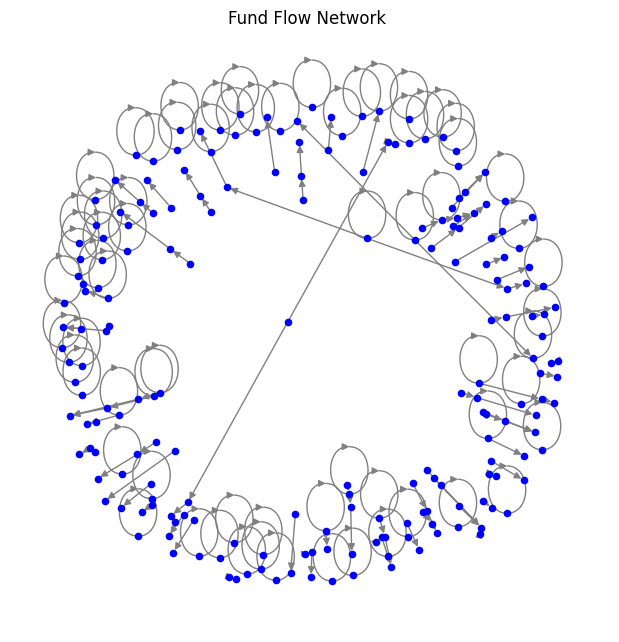

In [8]:
import matplotlib.pyplot as plt


small_G = G.subgraph(list(G.nodes())[:200])

plt.figure(figsize=(6,6))

nx.draw(
    small_G,
    node_size=20,
    node_color="blue",
    edge_color="gray",
    with_labels=False
)

plt.title("Fund Flow Network ")
plt.show()

In [9]:
import networkx as nx

cycles = list(nx.simple_cycles(G))

print("Total Circular Transactions:", len(cycles))

print("Example Circular Paths:")
for c in cycles[:5]:
    print(c)

Total Circular Transactions: 6269
Example Circular Paths:
['800104D70']
['800107150']
['80010E430']
['80010E650']
['80010EA80']


In [10]:
# self loops remove
G.remove_edges_from(nx.selfloop_edges(G))

cycles = list(nx.simple_cycles(G))

print("Circular Transactions (excluding self loops):", len(cycles))

for c in cycles[:5]:
    print(c)

Circular Transactions (excluding self loops): 0


In [11]:
top_accounts = transactions.groupby("Account")["Amount Paid"].sum()

top_accounts = top_accounts.sort_values(ascending=False)

print("Top 10 High Value Accounts:")
print(top_accounts.head(10))

Top 10 High Value Accounts:
Account
800C5E880    1.862265e+09
800BA91D0    1.742075e+09
800588840    1.236108e+09
8009B5D80    9.915806e+08
8003CEAB0    6.384422e+08
8002B8F00    5.304450e+08
800BEDEB0    5.178264e+08
80170CD90    3.849962e+08
80110CF30    3.002985e+08
100428660    2.864085e+08
Name: Amount Paid, dtype: float64


In [12]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.01)

transactions["anomaly"] = model.fit_predict(
    transactions[["Amount Paid"]]
)

print("Suspicious Transactions:")
print(transactions[transactions["anomaly"] == -1].head())

Suspicious Transactions:
            Timestamp  From Bank    Account  To Bank  Account.1  \
3    2022/09/01 00:03       1208  80010E650       20  80010E6F0   
4    2022/09/01 00:02       1208  80010E650       20  80010EA30   
29   2022/09/01 00:17          0  800A39060        0  800A39060   
202  2022/09/01 00:14         20  801DC70B0    15019  802376010   
286  2022/09/01 00:04       7141  80341F160     7141  80341F160   

     Amount Received Receiving Currency  Amount Paid Payment Currency  \
3        73966883.00          US Dollar  73966883.00        US Dollar   
4        45868454.00          US Dollar  45868454.00        US Dollar   
29       34776847.10          US Dollar  34776847.10        US Dollar   
202      40839293.00          US Dollar  40839293.00        US Dollar   
286      15957240.75          US Dollar  15957240.75        US Dollar   

    Payment Format  Is Laundering  anomaly  
3           Cheque              0       -1  
4           Cheque              0       -1 

In [13]:
print("Total Suspicious Transactions:")
print((transactions["anomaly"] == -1).sum())

Total Suspicious Transactions:
98


In [14]:
suspicious_accounts = transactions[transactions["anomaly"] == -1]

top_suspicious = suspicious_accounts["Account"].value_counts()

print("Top Suspicious Accounts:")
print(top_suspicious.head(10))

Top Suspicious Accounts:
Account
100428660    6
800C5E880    4
80010E650    2
8003376D0    2
8003CEAB0    2
800308EA0    2
8006D5FD0    2
800588840    2
80080E800    2
800BA91D0    2
Name: count, dtype: int64


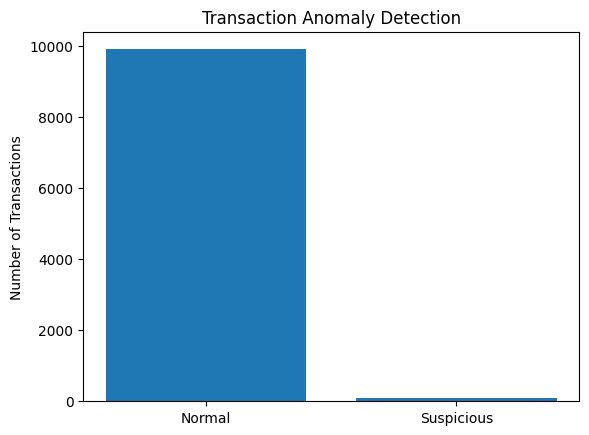

In [15]:
import matplotlib.pyplot as plt

counts = transactions["anomaly"].value_counts()

plt.bar(["Normal", "Suspicious"], [counts[1], counts[-1]])
plt.title("Transaction Anomaly Detection")
plt.ylabel("Number of Transactions")
plt.show()

In [16]:
suspicious = transactions[transactions["anomaly"] == -1]

suspicious.to_csv("suspicious_transactions.csv", index=False)

print("Suspicious transactions saved successfully.")

Suspicious transactions saved successfully.


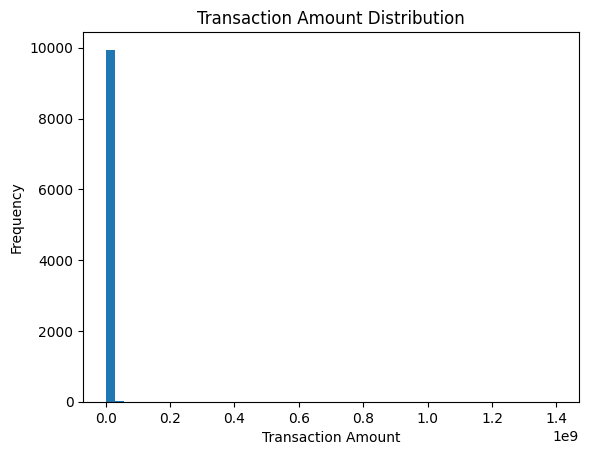

In [17]:
import matplotlib.pyplot as plt

plt.hist(transactions["Amount Paid"], bins=50)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

In [18]:
top_banks = transactions.groupby("From Bank")["Amount Paid"].sum()

print(top_banks.sort_values(ascending=False).head(10))

From Bank
0        3.228928e+09
2954     2.120025e+09
2597     1.600212e+09
1818     1.207033e+09
1601     1.110201e+09
11848    5.346323e+08
20       5.242824e+08
1208     5.165527e+08
23602    4.137861e+08
1924     3.397470e+08
Name: Amount Paid, dtype: float64


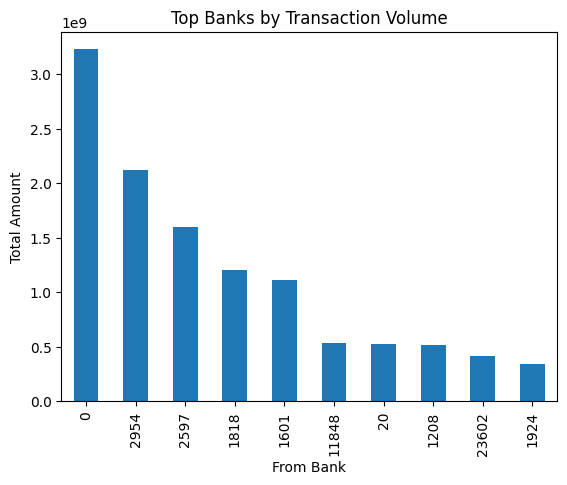

In [19]:
import matplotlib.pyplot as plt

top_banks = transactions.groupby("From Bank")["Amount Paid"].sum()

top_banks.sort_values(ascending=False).head(10).plot(kind="bar")

plt.title("Top Banks by Transaction Volume")
plt.ylabel("Total Amount")
plt.show()

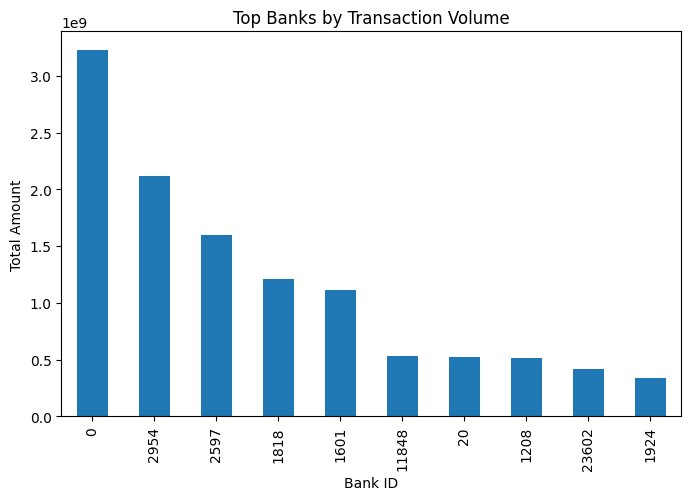

In [20]:
import matplotlib.pyplot as plt

top_banks = transactions.groupby("From Bank")["Amount Paid"].sum()

top10 = top_banks.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
top10.plot(kind="bar")

plt.title("Top Banks by Transaction Volume")
plt.ylabel("Total Amount")
plt.xlabel("Bank ID")

plt.show()

In [21]:
total = len(transactions)
suspicious = (transactions["anomaly"] == -1).sum()

percentage = (suspicious / total) * 100

print("Total Transactions:", total)
print("Suspicious Transactions:", suspicious)
print("Suspicious Percentage:", round(percentage,2), "%")

Total Transactions: 10000
Suspicious Transactions: 98
Suspicious Percentage: 0.98 %


In [22]:
print("Fund Flow Tracking System Summary")
print("----------------------------------")

print("Total Accounts:", G.number_of_nodes())
print("Total Transactions:", G.number_of_edges())

print("Suspicious Transactions:", (transactions["anomaly"] == -1).sum())

Fund Flow Tracking System Summary
----------------------------------
Total Accounts: 8387
Total Transactions: 1760
Suspicious Transactions: 98


In [23]:
sample = transactions.head(1000)
sample.to_csv("sample_transactions.csv", index=False)